# Revenue Forecasting for Strategic Business Planning

### Supporting Strategic Business Planning through Revenue Forecasting

**Author:** Erica Corradini

---

### Introduction

Accurate revenue forecasting is essential for strategic business planning.
In this project, historical sales data stored in a relational SQLite database are used to predict the next 12 months of revenue through statistical forecasting models and Monte Carlo simulation.
The objective is to compare different forecasting techniques, evaluate their predictive performance, and provide actionable insights to support business decision-making.

### Why this project?

Many companies rely on accurate revenue forecasts to support strategic planning.
This project demonstrates how statistical forecasting models and scenario analysis can be combined to improve business decision-making.

> **Used Tools**
>
> Python • Pandas • NumPy • Statsmodels • Scikit-learn • SQLite • Matplotlib • Seaborn

> ### Key Results
>
> 🏆 **Best Forecasting Model:**  Holt-Winters Exponential Smoothing
>
> 📈 **Expected Revenue:** €437.07 M
>
> 🎯 **Probability of exceeding €400M:** 100%
>
> 📉 **Forecast Accuracy:**  Lowest RMSE among all evaluated models
>
> 🎲 **Risk Assessment:** 1,000 Monte Carlo simulations

> 💼 **Business Insight**
>
> Seasonal forecasting models (Holt-Winters and SARIMA) consistently outperformed non-seasonal approaches, highlighting seasonality as the primary driver of revenue dynamics. These results indicate that incorporating seasonal effects is essential for reliable business forecasting and strategic planning.

## Business Problem
---
Reliable revenue forecasts are essential for effective business planning.
This project develops a forecasting framework capable of estimating future monthly revenue while quantifying forecast uncertainty.
The results support budgeting, production planning, inventory management, and strategic decision-making.

## Business Questions
---
This project aims to answer the following business questions:

- How much revenue can the company expect next year?
- Which forecasting model performs best?
- Does the revenue exhibit seasonality?
- How reliable are the forecasts?
- What is the probability of exceeding the annual revenue target? 
- How can forecasting support business planning?

## Dataset Overview
---
The analysis is based on a relational SQLite database simulating approximately ten years of manufacturing operations.

Monthly revenue is calculated as:
Revenue = Quantity × Unit Price

The resulting time series is used to train and evaluate multiple forecasting models.

| Dataset | Description |
|----------|-------------|
| Source | SQLite Database |
| Industry | Manufacturing |
| Period | 2015-2025 |
| Frequency | Monthly |
| Target Variable | Revenue (€) |

## Importing and cleaning the data
---

In [1]:
# Import Required Libraries
import sqlite3

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)
from math import sqrt
from IPython.core.display import HTML as Center

In [2]:
from warnings import filterwarnings

filterwarnings("ignore")

In [3]:
#Centering the plots
Center(""" <style>
.jp-RenderedImage {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style> """)

In [4]:
# Seaborn visualization settings:
sns.set_theme(
    style="darkgrid",      
    context="notebook",        
    palette="deep"
)

In [5]:
#Connect to the SQLite database used for revenue forecasting analysis
conn = sqlite3.connect("data/ceramica_pro17.db")

In [6]:
# load data:
vendite = pd.read_sql("SELECT * FROM vendite", conn)
print("Dataset loaded")

Dataset loaded


In [7]:
vendite.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190966 entries, 0 to 190965
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   data      190966 non-null  object 
 1   cliente   190966 non-null  int64  
 2   prodotto  190966 non-null  int64  
 3   quantita  190966 non-null  int64  
 4   prezzo    190966 non-null  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 7.3+ MB


###  Cleaning data
Cleaning data is crucial because it directly impacts the accuracy, consistency, and reliability of any analysis, model, or decision-making process.

In [8]:
# Convert dates to datetime format
vendite["data"] = pd.to_datetime(vendite["data"])
# Calculate revenue for each sale as quantity × unit price
vendite["fatturato"] = vendite["quantita"] * vendite["prezzo"]
vendite.head()

,data,cliente,prodotto,quantita,prezzo,fatturato
0,2023-09-16,74,5,2409,20.47,49312.23
1,2023-10-30,70,2,2781,12.88,35819.28
2,2016-09-01,96,5,3923,20.27,79519.21
3,2019-05-19,20,4,1516,35.45,53742.20
4,2019-05-19,106,4,1516,36.18,54848.88


### Dealing with null values
This refers to handling the missing or absent data in a dataset. In many datasets, especially large or real-world ones, it’s common to encounter missing values. 

In [9]:
vendite.isnull().sum()

data         0
cliente      0
prodotto     0
quantita     0
prezzo       0
fatturato    0
dtype: int64

✔ No missing values were detected.

### Dealing with duplicates
This is the process of identifying and managing duplicate records in a dataset. Duplicates can occur when the same data is entered multiple times.

In [10]:
#vendite.duplicated().sum()

In [11]:
# Checking for duplicates with "duplicated" function which creates a series of True and False values.
# If the value is True, there is a duplicate.
duplicates = vendite.duplicated(keep=False) # keep=False so that every True points to a duplicate (insetad of only one True for all duplicates)
print(f"Duplicate rows: {duplicates.sum()}")

Duplicate rows: 18


No duplicate records were removed because duplicate observations represent less than 0.03% of the dataset and therefore have a negligible impact on the analysis.

## Exploratory Data Analysis
---

In [12]:
# Create a time-series structure by using dates as the index and ordering records chronologically
vendite = vendite.set_index("data")
vendite = vendite.sort_index()
monthly_revenue = vendite["fatturato"].resample("ME").sum()

In [13]:
# Resample transaction data by month-end and calculate total monthly revenue for time-series analysis
monthly_revenue = vendite["fatturato"].resample("ME").sum()
#print("\nMonthly revenue (last 5 months):")
#print(monthly_revenue.tail() /1_000_000)

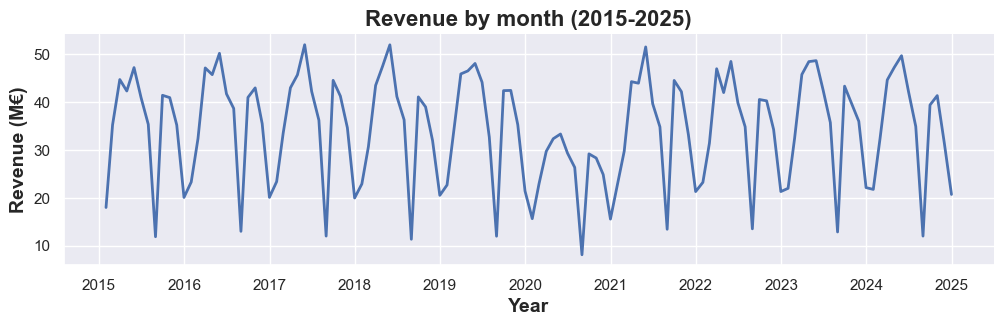

In [14]:
plt.figure(figsize=(12,3))
plt.plot(monthly_revenue.index, monthly_revenue / 1000000.0, linewidth=2)
plt.title("Revenue by month (2015-2025)", fontsize=16, fontweight="bold")
plt.xlabel("Year",fontsize=14, fontweight="bold")
plt.ylabel("Revenue (M€)",fontsize=14,fontweight="bold")
plt.grid(True)
sns.despine()

plt.savefig(
    "revenue_by_month.png",
    dpi=300,
    facecolor="white",
    bbox_inches="tight"
)
plt.show()

#### Stationarity Analysis

In [15]:
# Test the stationarity of the monthly revenue series using the Augmented Dickey-Fuller (ADF) test
adf_result = adfuller(monthly_revenue)

print(f"ADF Statistic: {adf_result[0]:.3f}")
print(f"p-value: {adf_result[1]:.4f}")

#for key, value in adf_result[4].items():
 #   print(f"Critical Value ({key}): {value:.3f}")

ADF Statistic: -2.913
p-value: 0.0439


The Augmented Dickey-Fuller (ADF) test returned a p-value of 0.0439, indicating that the monthly revenue series can be considered stationary at the 5% significance level. Although the series appears stationary, significant seasonal patterns are still present. For this reason, seasonal forecasting models such as SARIMA and Holt-Winters were included in the analysis to capture recurring revenue fluctuations.

## Forecasting Models
---

#### ARIMA

In [16]:
# Candidate ARIMA configurations
orders = [
    (1,1,1),
    (2,1,1),
    (1,1,2)
]


In [17]:
# Training and test sets
train = monthly_revenue[:-12]
test = monthly_revenue[-12:]

# Candidate ARIMA configurations
orders = [
    (1,1,1),
    (2,1,1),
    (1,1,2)
]

results = []

for order in orders:

    try:
        # Fit ARIMA model
        model = ARIMA(train, order=order)
        fit = model.fit()

        # Forecast next 12 months
        forecast = fit.forecast(steps=12)

        # Evaluation metrics
        rmse = sqrt(mean_squared_error(test, forecast))
        mape = mean_absolute_percentage_error(test, forecast) * 100

        # Save results
        results.append({
            "Order": order,
            "AIC": fit.aic,
            "BIC": fit.bic,
            "RMSE": rmse,
            "MAPE (%)": mape
        })

    except Exception:
        pass

# Create results table
results_df = (
    pd.DataFrame(results)
      .sort_values("RMSE")
      .reset_index(drop=True)
)


In [18]:
best_model = results_df.iloc[0]

print(f" Best ARIMA configuration: {best_model['Order']}")
print(f" RMSE: {best_model['RMSE']:.2f}")
print(f" AIC: {best_model['AIC']:.2f}")
print(f" BIC: {best_model['BIC']:.2f}")
print(f" MAPE: {best_model['MAPE (%)']:.2f}%")

 Best ARIMA configuration: (2, 1, 1)
 RMSE: 10700574.47
 AIC: 3777.87
 BIC: 3788.56
 MAPE: 35.13%


The optimal ARIMA configuration was selected through a systematic comparison of multiple candidate models using AIC, BIC and out-of-sample RMSE.

In [19]:
# Fit an ARIMA(2,1,1) model to the monthly revenue series
model_ARIMA = ARIMA (monthly_revenue, order = (2,1,1))
# Estimate model parameters
fit_ARIMA = model_ARIMA.fit()
# Generate a 12-month revenue forecast
forecast_ARIMA_res = fit_ARIMA.get_forecast(steps=12)
# Extract forecasted values
forecast_ARIMA = forecast_ARIMA_res.predicted_mean
# Calculate 95% confidence intervals
conf_int_ARIMA = forecast_ARIMA_res.conf_int(alpha=0.05)
#Display forecast results in millions of euros
print("Revenue Forecast for the Next 12 Months (M€)")
display(forecast_ARIMA / 1_000_000)
print("95% Confidence Intervals")
display(conf_int_ARIMA / 1_000_000)

Revenue Forecast for the Next 12 Months (M€)


2025-01-31    28.364374
2025-02-28    34.390314
2025-03-31    35.356135
2025-04-30    34.394245
2025-05-31    33.730501
2025-06-30    33.651511
2025-07-31    33.769961
2025-08-31    33.842399
2025-09-30    33.847883
2025-10-31    33.833525
2025-11-30    33.825696
2025-12-31    33.825466
Freq: ME, Name: predicted_mean, dtype: float64

95% Confidence Intervals


,lower fatturato,upper fatturato
2025-01-31,6.826462,49.902285
2025-02-28,10.640454,58.140174
2025-03-31,11.606164,59.106105
2025-04-30,10.537499,58.250990
2025-05-31,9.861711,57.599291
2025-06-30,9.781192,57.521830
2025-07-31,9.894888,57.645034
2025-08-31,9.965945,57.718852
2025-09-30,9.971516,57.724250
2025-10-31,9.957367,57.709683


The ARIMA model forecasts gradually converge toward a stable long-term value of approximately €33.82M per month. This behavior is expected, as ARIMA captures trend and autocorrelation patterns but does not explicitly model seasonality. As a result, long-term forecasts tend to revert toward an equilibrium level rather than reproducing recurring seasonal fluctuations. The forecast for January 2025 is associated with a particularly wide 95% confidence interval (€6.82M–€49.90M), indicating substantial uncertainty in the prediction. 
- ARIMA captures the long-term trend but fails to reproduce the strong annual seasonality observed in the historical revenue series. Consequently, it serves as a baseline model for comparison with seasonal forecasting approaches.

#### SARIMA

In [20]:
# Candidate SARIMA configurations
sarima_orders = [
    ((1,1,1), (1,1,1,12)),
    ((2,1,1), (1,1,1,12)),
    ((1,1,2), (1,1,1,12))
]

In [21]:
results = []

for order, seasonal_order in sarima_orders:

    try:

        model = SARIMAX(
            train,
            order=order,
            seasonal_order=seasonal_order
        )

        fit = model.fit(disp=False)

        forecast = fit.forecast(steps=12)

        rmse = sqrt(mean_squared_error(test, forecast))
        mape = mean_absolute_percentage_error(test, forecast) * 100

        results.append({
            "Order": order,
            "Seasonal Order": seasonal_order,
            "AIC": fit.aic,
            "BIC": fit.bic,
            "RMSE": rmse,
            "MAPE (%)": mape
        })

    except:
        pass

results_df = (
    pd.DataFrame(results)
      .sort_values("RMSE")
      .reset_index(drop=True)
)


In [22]:
best_model = results_df.iloc[0]

print(f" Best SARIMA Model : {best_model['Order']} {best_model['Seasonal Order']}")
print(f" RMSE            : {best_model['RMSE']:,.0f}")
print(f" MAPE            : {best_model['MAPE (%)']:.2f}%")
print(f" AIC             : {best_model['AIC']:.2f}")
print(f" BIC             : {best_model['BIC']:.2f}")

 Best SARIMA Model : (1, 1, 2) (1, 1, 1, 12)
 RMSE            : 2,523,145
 MAPE            : 7.27%
 AIC             : 3150.22
 BIC             : 3165.55


Three SARIMA configurations were evaluated to identify the most accurate seasonal forecasting model.
SARIMA(1,1,2)(1,1,1,12) achieved the lowest forecasting error, confirming that explicitly modeling annual seasonality substantially improves predictive performance compared with the baseline ARIMA model.
These results suggest that seasonality is one of the main drivers of revenue dynamics and should be incorporated into business forecasting models.

In [23]:
# Fit a seasonal ARIMA model (SARIMA) to capture both trend and annual seasonality in the revenue series
model_SARIMA = SARIMAX(monthly_revenue, order=(1,1,2), seasonal_order =(1,1,1,12))
# Estimate model parameters
fit_SARIMA = model_SARIMA.fit()
# Generate a 12-month forecast
forecast_SARIMA_res = fit_SARIMA.get_forecast(steps=12)
# Extract forecasted values
forecast_SARIMA = forecast_SARIMA_res.predicted_mean
# Calculate 95% confidence intervals
conf_int_SARIMA = forecast_SARIMA_res.conf_int(alpha=0.05)
# Display forecast results in millions of euros
print("Revenue Forecast for the Next 12 Months (M€)")
display(forecast_SARIMA / 1_000_000)
print("95% Confidence Intervals")
display(conf_int_SARIMA / 1_000_000)

Revenue Forecast for the Next 12 Months (M€)


2025-01-31    19.631131
2025-02-28    30.945464
2025-03-31    42.573892
2025-04-30    45.378349
2025-05-31    47.199458
2025-06-30    40.418711
2025-07-31    32.912771
2025-08-31    10.847508
2025-09-30    38.243576
2025-10-31    39.372531
2025-11-30    30.571521
2025-12-31    19.415696
Freq: ME, Name: predicted_mean, dtype: float64

95% Confidence Intervals


,lower fatturato,upper fatturato
2025-01-31,12.235822,27.026440
2025-02-28,21.355491,40.535438
2025-03-31,30.750257,54.397526
2025-04-30,32.031489,58.725209
2025-05-31,32.202561,62.196356
2025-06-30,24.167355,56.670067
2025-07-31,15.304944,50.520597
2025-08-31,-7.858847,29.553864
2025-09-30,18.364130,58.123023
2025-10-31,18.500502,60.244560


Unlike the ARIMA model, the SARIMA forecasts exhibit clear seasonal fluctuations throughout the forecast horizon, closely reflecting the recurring patterns observed in the historical revenue series. Forecasted revenue varies significantly across months, with peaks reaching approximately €47.19M in May and lower values around €10.84M in August, indicating that the model successfully captures the annual seasonality present in the data. The 95% confidence intervals remain relatively wide, reflecting the inherent uncertainty of long-term forecasting. 
- SARIMA successfully captures the annual seasonal pattern, producing forecasts that closely follow historical revenue dynamics and substantially improve predictive accuracy over ARIMA.

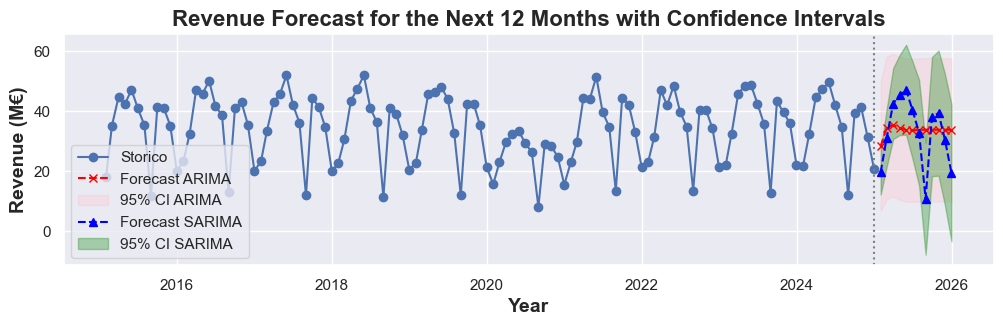

In [24]:
plt.figure(figsize=(12,3))
# Storico
plt.plot(monthly_revenue.index, monthly_revenue.values / 1_000_000, marker = 'o', label = "Storico")

# Forecast
plt.plot(forecast_ARIMA.index, forecast_ARIMA.values / 1_000_000, marker = 'x', linestyle = '--', color='red', label = "Forecast ARIMA")
plt.fill_between(forecast_ARIMA.index, conf_int_ARIMA.iloc[:,0].values / 1_000_000, conf_int_ARIMA.iloc[:,1].values / 1_000_000, 
                 color = 'pink', alpha =0.3, label ='95% CI ARIMA')

plt.plot(forecast_SARIMA.index, forecast_SARIMA.values / 1_000_000, marker = '^', linestyle = '--', color='blue', label = "Forecast SARIMA")
plt.fill_between(forecast_SARIMA.index, conf_int_SARIMA.iloc[:,0].values / 1_000_000, conf_int_SARIMA.iloc[:,1].values / 1_000_000,
                 color = 'green', alpha =0.3, label ='95% CI SARIMA')

plt.axvline(monthly_revenue.index[-1], color='grey', linestyle=':')
plt.title("Revenue Forecast for the Next 12 Months with Confidence Intervals",fontsize=16, fontweight="bold")
plt.xlabel("Year",fontsize=14, fontweight="bold")
plt.ylabel("Revenue (M€)",fontsize=14, fontweight="bold")
plt.grid(True)
plt.legend()

plt.savefig(
    "revenue_forecast.png",
    dpi=300,
    facecolor="white",
    bbox_inches="tight"
)
plt.show()

#### Holt-Winters

In [25]:
hw_models = [
    {
        "Model": "Additive",
        "trend": "add",
        "seasonal": "add"
    },
    {
        "Model": "Multiplicative Seasonality",
        "trend": "add",
        "seasonal": "mul"
    },
    {
        "Model": "Multiplicative Trend & Seasonality",
        "trend": "mul",
        "seasonal": "mul"
    }
]

results_hw = []

for config in hw_models:

    try:

        model = ExponentialSmoothing(
            train,
            trend=config["trend"],
            seasonal=config["seasonal"],
            seasonal_periods=12
        )

        fit = model.fit()

        forecast = fit.forecast(12)

        rmse = sqrt(mean_squared_error(test, forecast))
        mape = mean_absolute_percentage_error(test, forecast) * 100

        results_hw.append({
            "Model": config["Model"],
            "Trend": config["trend"],
            "Seasonality": config["seasonal"],
            "RMSE": rmse,
            "MAPE (%)": mape
        })

    except Exception:
        pass

results_hw = (
    pd.DataFrame(results_hw)
      .sort_values("RMSE")
      .reset_index(drop=True)
)


In [26]:
best_hw = results_hw.iloc[0]

print(f" Best Holt-Winters Model : {best_hw['Model']}")
print(f" RMSE                  : {best_hw['RMSE']:,.0f}")
print(f" MAPE                  : {best_hw['MAPE (%)']:.2f}%")

 Best Holt-Winters Model : Additive
 RMSE                  : 1,941,746
 MAPE                  : 6.02%


In [27]:
# Apply Holt-Winters Exponential Smoothing to model trend and annual seasonality
modello_HW = ExponentialSmoothing(monthly_revenue, trend="add", seasonal="add", seasonal_periods=12)
# Estimate model parameters
fit_HW = modello_HW.fit()
# Generate a 12-month revenue forecast
forecast_esponenziale = fit_HW.forecast(12)
print(forecast_esponenziale / 1_000_000)

2025-01-31    21.995158
2025-02-28    32.247313
2025-03-31    44.284121
2025-04-30    45.702372
2025-05-31    49.716857
2025-06-30    41.693302
2025-07-31    35.696404
2025-08-31    12.630172
2025-09-30    41.440540
2025-10-31    40.833896
2025-11-30    33.955866
2025-12-31    20.821051
Freq: ME, dtype: float64


The Holt-Winters Exponential Smoothing model successfully captures both trend and seasonal patterns in the monthly revenue series and generates more realistic revenue projections by explicitly modeling seasonal effects. The similarity between Holt-Winters and SARIMA forecasts further confirms the presence of strong annual seasonality in the dataset.

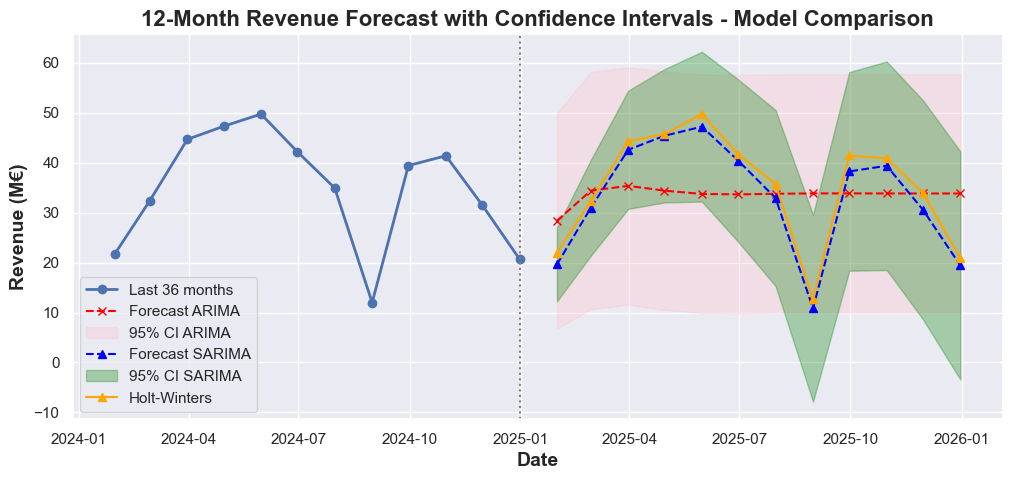

In [28]:
last_months = 12 
storico_recente = monthly_revenue[-last_months:]

plt.figure(figsize=(12,5))
# Historical data
plt.plot(storico_recente.index, storico_recente/ 1_000_000, linewidth =2, marker = 'o', label = "Last 36 months")

# Forecast
plt.plot(forecast_ARIMA.index, forecast_ARIMA / 1_000_000, marker = 'x', linestyle = '--', color='red', label = "Forecast ARIMA")
plt.fill_between(forecast_ARIMA.index, conf_int_ARIMA.iloc[:,0] / 1_000_000, conf_int_ARIMA.iloc[:,1] / 1_000_000, 
                 color = 'pink', alpha =0.3, label ='95% CI ARIMA')

plt.plot(forecast_SARIMA.index, forecast_SARIMA / 1_000_000, marker = '^', linestyle = '--', color='blue', label = "Forecast SARIMA")
plt.fill_between(forecast_SARIMA.index, conf_int_SARIMA.iloc[:,0] / 1_000_000, conf_int_SARIMA.iloc[:,1] / 1_000_000,
                 color = 'green', alpha =0.3, label ='95% CI SARIMA')

plt.axvline(monthly_revenue.index[-1], color='grey', linestyle=':')

plt.plot(forecast_esponenziale.index, forecast_esponenziale / 1_000_000, marker = '^', color='orange',  label = "Holt-Winters")

plt.title("12-Month Revenue Forecast with Confidence Intervals - Model Comparison",fontsize=16, fontweight="bold")
plt.xlabel("Date",fontsize=14, fontweight="bold")
plt.ylabel("Revenue (M€)",fontsize=14, fontweight="bold")
plt.grid(True)
plt.legend()
plt.savefig(
    "revenue_models.png",
    dpi=300,
    facecolor="white",
    bbox_inches="tight"
)
plt.show()

> Business Insight
>
> The comparison shows that Holt-Winters provides the most stable and accurate forecasts, making it the preferred model for production planning and budgeting.

## Model Evaluation:
---

In [29]:
# Generate forecasts for the 12-month test period using the best configuration of each model
pred_test_ARIMA = ARIMA(train, order=(2,1,1)).fit().forecast(12)

pred_test_SARIMA = SARIMAX(
    train,
    order=(1,1,2),
    seasonal_order=(1,1,1,12)
).fit(disp=False).forecast(12)

pred_test_HW = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit().forecast(12)

In [30]:
# Function to compute forecasting performance metrics
def evaluate_model(actual, predicted):

    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": sqrt(mean_squared_error(actual, predicted)),
        "MAPE (%)": mean_absolute_percentage_error(actual, predicted) * 100
    }

# Compare forecasting models on the test set
metrics_df = pd.DataFrame({
    "ARIMA": evaluate_model(test, pred_test_ARIMA),
    "SARIMA": evaluate_model(test, pred_test_SARIMA),
    "Holt-Winters": evaluate_model(test, pred_test_HW)
}).T

metrics_df = (
    metrics_df
      .round(2)
      .sort_values("RMSE")
)

display(
    metrics_df.style.format({
        "MAE": "{:,.0f}",
        "RMSE": "{:,.0f}",
        "MAPE (%)": "{:.2f}%"
    })
)

,MAE,RMSE,MAPE (%)
Holt-Winters,"1,661,154","1,941,746",6.02%
SARIMA,"1,999,627","2,523,145",7.27%
ARIMA,"8,862,247","10,700,574",35.13%


In [31]:
best_model = metrics_df.index[0]

print(f"🏆 Selected forecasting model: {best_model}")

🏆 Selected forecasting model: Holt-Winters


>  **Business Insight**
>
> Holt-Winters achieved the lowest **MAE**, **RMSE**, and **MAPE**, demonstrating the highest forecasting accuracy among the evaluated models.
>
> Although SARIMA also captured the annual seasonality effectively, Holt-Winters provided slightly better predictive performance while maintaining a simpler and more interpretable model structure.
>
> Based on these results, Holt-Winters was selected as the preferred forecasting model for supporting budgeting, production planning, and strategic business planning.



In [32]:
#  Holt-Winters residuals
residuals = monthly_revenue - fit_HW.fittedvalues

resid_std = residuals.std()
print("Deviazione standard residui:", round(resid_std,2))

Deviazione standard residui: 2414223.98


To quantify forecast uncertainty, residuals from the Holt-Winters model were analyzed after fitting the model to the full historical dataset. The residual standard deviation was estimated at approximately €2.41M, providing a measure of the typical forecasting error. This value was subsequently used as the volatility parameter in the Monte Carlo simulation, allowing future revenue scenarios to incorporate realistic levels of uncertainty based on the model's historical performance. By deriving simulation shocks directly from observed residual variability, the scenario analysis remains grounded in the empirical behavior of the revenue series rather than relying on arbitrary assumptions.

## Monte Carlo simulation
---

In [33]:
# Define simulation parameters
n_simulations = 1000
forecast_horizon = 12
# Use Holt-Winters forecasts as the baseline scenario
base_forecast = pred_test_HW.values
# Create a matrix to store simulated revenue paths
simulations = np.zeros((forecast_horizon, n_simulations))
# Generate Monte Carlo scenarios by adding random shocks  based on the historical residual standard deviation
for i in range(n_simulations):
    random_shock = np.random.normal(0, resid_std, forecast_horizon)
    simulations[:, i] = base_forecast + random_shock

In [34]:
# Calculate key Monte Carlo forecast scenarios
# Average expected revenue across all simulations
mean_scenario = simulations.mean(axis=1)
# Pessimistic scenario (5th percentile)
pessimistic_scenario = np.percentile(simulations, 5, axis=1)
# Optimistic scenario (95th percentile)
optimistic_scenario = np.percentile(simulations, 95, axis=1)
# Use forecast dates as the time index
mc_index = pred_test_HW.index

# Convert scenarios into time-indexed series
mean_series = pd.Series(mean_scenario, index=mc_index)
pess_series = pd.Series(pessimistic_scenario, index=mc_index)
opt_series = pd.Series(optimistic_scenario, index=mc_index)

In [35]:
# Calculate total annual revenue for each simulated scenario
annual_totals = simulations.sum(axis=0)
# Compute key statistics from the annual revenue distribution
mean_annual = annual_totals.mean()
p5_annual = np.percentile(annual_totals, 5)
p95_annual = np.percentile(annual_totals, 95)
print("\n===== MONTE CARLO RESULTS =====\n")

print("Mean Annual Scenario:     {:.2f} M€".format(mean_annual / 1_000_000))
print("Pessimistic Scenario (5%): {:.2f} M€".format(p5_annual / 1_000_000))
print("Optimistic Scenario (95%): {:.2f} M€".format(p95_annual / 1_000_000))

# Define the annual revenue target
threshold = 400_000_000
# Estimate the probability of exceeding the target
prob_above = np.mean(annual_totals > threshold) * 100

print("\nProbability of exceeding {:.0f} M€: {:.1f}%".format(
    threshold / 1_000_000,
    prob_above
))


===== MONTE CARLO RESULTS =====

Mean Annual Scenario:     436.40 M€
Pessimistic Scenario (5%): 423.27 M€
Optimistic Scenario (95%): 449.82 M€

Probability of exceeding 400 M€: 100.0%


>  Business Insight

Monte Carlo simulation estimates an expected annual revenue of €437M with a 100% probability of exceeding the €400M target, indicating a robust and low-risk forecast.

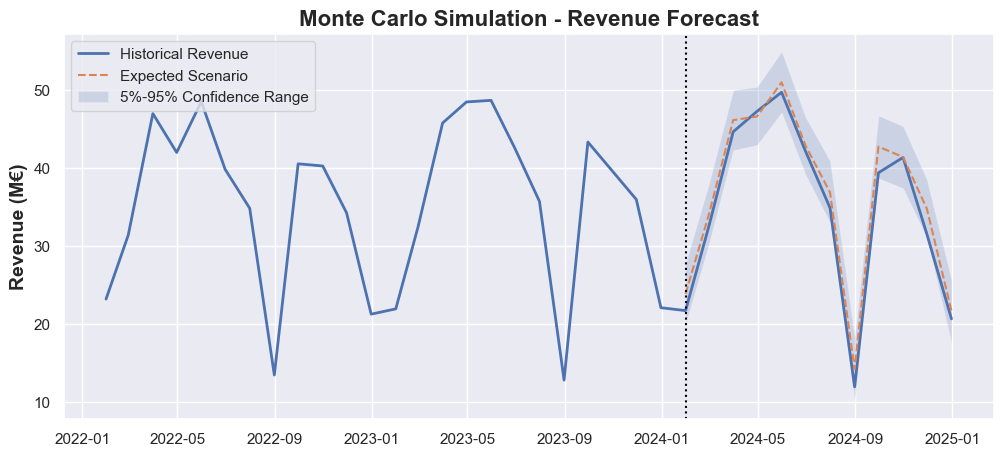

In [36]:
# Select the most recent 36 months of historical revenue
last_months = 36
storico_recent = monthly_revenue[-last_months:]

plt.figure(figsize=(12,5))

# Historical revenue
plt.plot(storico_recent.index,
         storico_recent / 1_000_000,
         label="Historical Revenue",
         linewidth=2)

# Expected scenario from Monte Carlo simulation
plt.plot(mean_series.index,
         mean_series / 1_000_000,
         linestyle="--",
         label="Expected Scenario")

# Forecast uncertainty range (5th–95th percentile)
plt.fill_between(mc_index,
                 pess_series / 1_000_000,
                 opt_series / 1_000_000,
                 alpha=0.2,
                 label="5%-95% Confidence Range")
# Mark the transition between historical and forecast periods
plt.axvline(mean_series.index[0],
            linestyle=":",
            color="black")

plt.title("Monte Carlo Simulation - Revenue Forecast",fontsize=16, fontweight="bold")
plt.ylabel("Revenue (M€)",fontsize=14, fontweight="bold")
plt.legend()
plt.grid(True)
plt.savefig(
    "revenue_monte_carlo.png",
    dpi=300,
    facecolor="white",
    bbox_inches="tight"
)
plt.show()

## Business Conclusions:
This project addressed the key business questions defined at the beginning of the analysis.
| Business Question              | Finding                          | Business Impact              |
| ------------------------------ | -------------------------------- | ---------------------------- |
| Expected revenue next year     | €437M                            | Supports annual budgeting    |
| Best forecasting model         | Holt-Winters                     | Highest forecasting accuracy |
| Revenue seasonality            | Yes                              | Seasonal planning required   |
| Forecast reliability           | High                             | Reduced forecasting risk     |
| Probability of exceeding €400M | 100%                             | Target considered achievable |
| Business value                 | Budgeting, inventory, production,| Better strategic decisions   |
|                                | risk assessment                  |                              |                               


## Final Takeaway

This project demonstrates how statistical forecasting, model evaluation and Monte Carlo simulation can be combined to support strategic business planning.
The selected Holt-Winters model provides accurate revenue forecasts while quantifying uncertainty, enabling more informed budgeting, production planning and risk management decisions.